In [ ]:
# first cell just imports all the necessary packages, functions, and classes
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from analysis_classes import *
from analysis_funcs_and_consts import *
#set font to arial
plt.rcParams['font.family'] = 'Arial'


In [2]:
#auto reload
%load_ext autoreload
%autoreload 2
from analysis_classes import *
from analysis_funcs_and_consts import *

In [3]:
#just to get a dictionary with all cells
db_Analysis = DB_Analysis()
db_conditions = {(True, STRAIN) :['CKII', 'SST']} # get both CKII and SST cells
cell_objects = db_Analysis.collect_cells(db_conditions, all=False)

In [5]:
with open('data_analysis/result_dictionaries/FR_mats_with_halves_all_cells.pkl', 'rb') as f:
    FR_mats_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_PC_with_halves_all_cells.pkl', 'rb') as f:
    is_PC_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/speed_r_vals_with_halves_all_cells.pkl', 'rb') as f:
    speed_r_vals_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_speed_tuned_with_halves_all_cells.pkl', 'rb') as f:
    is_speed_tuned_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/inst_speed_r_vals_with_halves_all_cells.pkl', 'rb') as f:
    inst_speed_r_vals_with_halves_all_cells = pickle.load(f)
with open('data_analysis/result_dictionaries/is_spatially_modulated_all_cells.pkl', 'rb') as f:
    is_spatially_modulated_all_cells = pickle.load(f)


# 7b

In [3]:
RZ = [53,64]

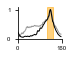

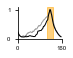

In [10]:
tick_size = 6
figsize_mm = (20, 15)
figsize_inches = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
remap_df = pd.read_excel(SOURCE_DATA_DIR + r"\7b.xlsx")
for j in [1, 5]:
    plt.figure(figsize=figsize_inches)

    df = remap_df[remap_df['trial'] == j]

    plt.plot(
        df['position_bin'],
        df['novel_norm_lick'],
        '-',
        color='0.6',
        linewidth=1,
        label='Novel'
    )

    plt.plot(
        df['position_bin'],
        df['familiar_norm_lick'],
        '-',
        color='k',
        linewidth=1,
        label='Familiar'
    )

    plt.xlim(0, 80)
    plt.ylim(0, 1.1)

    plt.xticks(
        np.linspace(0, 80, 2),
        np.linspace(0, 160, 2).astype(int),
        fontsize=tick_size
    )

    plt.yticks(
        np.linspace(0, 1, 2),
        np.linspace(0, 1, 2).astype(int),
        fontsize=tick_size
    )

    # reward zone
    plt.axvspan(RZ[0], RZ[1], alpha=0.5, color='orange')

    # styling
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor('none')

    plt.tick_params(axis='both', which='major', labelsize=tick_size)

    plt.savefig(
        f'lick_rate_remapping_trial{j}.svg',
        format='svg',
        dpi=300,
        bbox_inches='tight',
        transparent=True
    )

    plt.show()


# 7c

In [5]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_single_cell_heatmap_remap(cell,part='first_half',save=False, with_colorbar=False,max_val=None):
    FR_mat = FR_mats_with_halves_all_cells[cell.strain][cell.name][part]
    FR_vec=np.mean(FR_mat,axis=0)
    FR_vec = smooth(FR_vec,3)
    if max_val == None:
        max_val=np.round(np.max(FR_vec),1)
    figsize_mm = (16, 16)
    if with_colorbar:
        # Add extra space for the colorbar, e.g., 5mm
        additional_width_mm = figsize_mm[0] * (0.335) # 20 * 0.15 = 3mm 0.05 is for the colorbar, 0.1 is for the padding
        figsize_mm = (figsize_mm[0] + additional_width_mm, figsize_mm[1])
    figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)

    img = ax.imshow(FR_mat, aspect='auto', cmap='viridis')
    yticks_labels = [FR_mat.shape[0]]
    plt.yticks([FR_mat.shape[0] - 1], yticks_labels, fontsize=SVG_TICKS)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_tick_params(width=0,pad=0)

    ax2 = ax.twinx()
    ax2.plot(FR_vec, color='#e6e6e6', linewidth=1)
    ax2.set_ylim(0, max_val)
    ax2.set_yticks([])
    if cell.name == 'SRK1_X_39_1':
        xticks_labels = [0, 160]
        ax.set_xticks([0, 47], xticks_labels, fontsize=SVG_TICKS)
    else:
        ax.set_xticks([])

    #remove top and right spines
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.yaxis.set_tick_params(width=0,pad=0)
    img.set_clim(0, max_val*2) #used to be 0, max_val*1.5
    # make background transparent
    fig.patch.set_alpha(0)
    if with_colorbar:
        cbar = fig.colorbar(img, ax=ax, orientation='vertical', pad=0.1, aspect=15)#, shrink=0.5)
        cbar.set_ticks([0, max_val*2])
        cbar.set_ticklabels([0, max_val*2])
        cbar.ax.tick_params(labelsize=SVG_TICKS)
        cbar.outline.set_visible(False)
        cbar.ax.yaxis.set_tick_params(width=0,pad=0)
    if save:
        plt.savefig("your_save_path_here.svg", format='svg', dpi=300, bbox_inches='tight')
    plt.show()

def plot_cell_pair_heatmap_remap(cell, save=False, with_colorbar=False):
    FR_mat1 = FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half']
    FR_mat2 = FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half']
    FR_vec1 = np.mean(FR_mat1, axis=0)
    FR_vec2 = np.mean(FR_mat2, axis=0)
    FR_vec1 = smooth(FR_vec1, 3)
    FR_vec2 = smooth(FR_vec2, 3)
    max_val = np.round(np.max([FR_vec1, FR_vec2]), 1)
    plot_single_cell_heatmap_remap(cell, part='first_half', save=save, with_colorbar=False, max_val=max_val)
    plot_single_cell_heatmap_remap(cell, part='second_half', save=save, with_colorbar=with_colorbar, max_val=max_val)

RCK10_R1_22_8


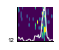

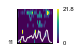

CRK8_R1_22_4


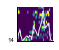

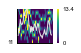

SRK1_R1_66_2


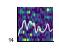

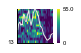

SRK1_R1_66_3


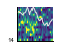

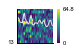

RCK5_L1_61_2


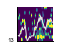

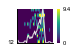

In [6]:
example_names = ['RCK5_L1_61_2', 'CRK8_R1_22_4', 'RCK10_R1_22_8', 'SRK1_R1_66_2', 'SRK1_R1_66_3']
remap_cells_lst = [cell for cell in cell_objects if cell.name in example_names]
for cell in remap_cells_lst:
    print(cell.name)
    plot_cell_pair_heatmap_remap(cell, save=False, with_colorbar=True)


# 7d

In [6]:
remap_cells = [cell for cell in cell_objects if cell.remapping==True and cell.session_num==0]                                                                                                                          
reg_cells = [cell for cell in cell_objects if cell.remapping==False and cell.session_num==0]

In [69]:
#split the strains for different criteria in each strain
len_vec=48
CKII_reg1=np.zeros(len_vec);CKII_reg2=np.zeros(len_vec)
CKII_fam=np.zeros(len_vec);CKII_nov=np.zeros(len_vec)
SST_reg1=np.zeros(len_vec);SST_reg2=np.zeros(len_vec)
SST_fam=np.zeros(len_vec);SST_nov=np.zeros(len_vec)
results_dict_to_export = {}
#remaps
for cell in remap_cells:
    # if is_PC_with_halves_all_cells[cell.strain][cell.name]['first_half']==False or is_PC_with_halves_all_cells[cell.strain][cell.name]['second_half']==False: # for untuned cells
    if is_PC_with_halves_all_cells[cell.strain][cell.name]['first_half']==True:
            if np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half'])==2 and np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half'])==2:
                FR_mat_fam = FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half']
                FR_mat_nov = FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half']
            else:
                continue
            FR_vec_fam=np.mean(FR_mat_fam,axis=0)
            FR_vec_fam=smooth(FR_vec_fam,3)
            FR_vec_nov=np.mean(FR_mat_nov,axis=0)
            FR_vec_nov=smooth(FR_vec_nov,3)
            results_dict_to_export[cell] = {'Condition':'Remap_Fam_tuned', 'first_half_FR_vec': FR_vec_fam, 'second_half_FR_vec': FR_vec_nov,
                                            'Corr': np.corrcoef(FR_vec_fam, FR_vec_nov)[0,1]}
            if cell.strain =="CKII":
                CKII_fam = np.vstack((CKII_fam,FR_vec_fam))
                CKII_nov = np.vstack((CKII_nov,FR_vec_nov))
            else:
                SST_fam = np.vstack((SST_fam,FR_vec_fam))
                SST_nov = np.vstack((SST_nov,FR_vec_nov))

#regs
for cell in reg_cells:
    # if is_PC_with_halves_all_cells[cell.strain][cell.name]['full']==False: # for untuned cells
    if is_PC_with_halves_all_cells[cell.strain][cell.name]['full']==True:
        if np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half'])==2 and np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half'])==2:
                FR_mat1 = FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half']
                FR_mat2 = FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half']
        else:
            continue
        FR_vec_1=np.mean(FR_mat1,axis=0)
        FR_vec_1=smooth(FR_vec_1,3)
        FR_vec_2=np.mean(FR_mat2,axis=0)
        FR_vec_2=smooth(FR_vec_2,3)
        results_dict_to_export[cell] = {'Condition':'Control_Fam1_tuned', 'first_half_FR_vec': FR_vec_1, 'second_half_FR_vec': FR_vec_2,
                                        'Corr': np.corrcoef(FR_vec_1, FR_vec_2)[0,1]}
        if cell.strain =="CKII":
            CKII_reg1 = np.vstack((CKII_reg1,FR_vec_1))
            CKII_reg2 = np.vstack((CKII_reg2,FR_vec_2))
        else:
            SST_reg1 = np.vstack((SST_reg1,FR_vec_1))
            SST_reg2 = np.vstack((SST_reg2,FR_vec_2))




In [32]:
#calc mean corr for each strain and condition based on the results_dict_to_export
import pandas as pd
results_list = []
for cell, data in results_dict_to_export.items():
    entry = {'Cell_ID': cell.identity, 'Strain': cell.strain, 'Condition': 'Control' if data['Condition']=='Control_Fam1_tuned' else 'Remap',
              'Corr': data['Corr']}
    results_list.append(entry)
results_df = pd.DataFrame(results_list)
#calculate mean and sem
mean_sems = results_df.groupby(['Strain', 'Condition'])['Corr'].agg(['mean', 'sem']).reset_index()
#also print len of each group
counts = results_df.groupby(['Strain', 'Condition']).size().reset_index(name='counts')
print(mean_sems)
    
    

  Strain Condition      mean       sem
0   CKII   Control  0.153034  0.022023
1   CKII     Remap  0.118061  0.024857
2    SST   Control  0.208741  0.023563
3    SST     Remap  0.136179  0.027837


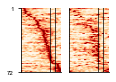

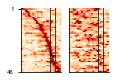

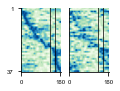

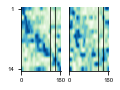

In [20]:
# SVG format
for strain in ['CKII','SST']:
    if strain=='CKII':
        spine_color=PYR_COLOR
        cmap = 'OrRd'
        mat_to_plot_reg1=CKII_reg1 ; mat_to_plot_reg2=CKII_reg2 ; mat_to_plot_fam=CKII_fam ; mat_to_plot_nov=CKII_nov
    else:
        spine_color=IN_COLOR
        cmap = 'GnBu'
        mat_to_plot_reg1=SST_reg1 ; mat_to_plot_reg2=SST_reg2 ; mat_to_plot_fam=SST_fam ; mat_to_plot_nov=SST_nov

    norm_mat_to_plot_reg1=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_reg1[1:]])
    norm_mat_to_plot_reg2=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_reg2[1:]])
    norm_mat_to_plot_fam=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_fam[1:]])
    norm_mat_to_plot_nov=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_nov[1:]])

    #if a row is NaN, replace it with zeros
    norm_mat_to_plot_reg1[np.isnan(norm_mat_to_plot_reg1)]=0 ; norm_mat_to_plot_reg2[np.isnan(norm_mat_to_plot_reg2)]=0; norm_mat_to_plot_fam[np.isnan(norm_mat_to_plot_fam)]=0; norm_mat_to_plot_nov[np.isnan(norm_mat_to_plot_nov)]=0; 

    sorted_norm_array_reg1,sorted_indices_reg1 = sort_rows_by_max_index(norm_mat_to_plot_reg1)
    sorted_norm_array_reg2=norm_mat_to_plot_reg2[sorted_indices_reg1]
    sorted_norm_array_fam,sorted_indices_fam = sort_rows_by_max_index(norm_mat_to_plot_fam)
    sorted_norm_array_nov=norm_mat_to_plot_nov[sorted_indices_fam]


    #plot as two subplots 
    figsize_mm = (40,30)
    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig,ax=plt.subplots(1,2,figsize=figsize_inch)
    ax[0].imshow(sorted_norm_array_reg1,aspect='auto',cmap=cmap)
    ax[0].set_yticks([0,(len(sorted_norm_array_reg1))-1],[1,len(sorted_norm_array_reg1)],fontsize=SVG_TICKS)
    if strain=='SST':
        ax[0].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[0].set_xticks([])

    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[0].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    ax[1].imshow(sorted_norm_array_reg2,aspect='auto',cmap=cmap)
    ax[1].set_yticks([])
    if strain=='SST':
        ax[1].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[1].set_xticks([])

    #remove top and right spines
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[1].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    #remove background color
    fig.patch.set_alpha(0)

    #add spacing between the two subplots
    plt.subplots_adjust(wspace=0.2)
    plt.show()

    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig,ax=plt.subplots(1,2,figsize=figsize_inch)
    ax[0].imshow(sorted_norm_array_fam,aspect='auto',cmap=cmap)
    ax[0].set_yticks([0,(len(sorted_norm_array_fam))-1],[1,len(sorted_norm_array_fam)],fontsize=SVG_TICKS)
    if strain=='SST':
        ax[0].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[0].set_xticks([])

    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[0].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    ax[1].imshow(sorted_norm_array_nov,aspect='auto',cmap=cmap)
    ax[1].set_yticks([])
    if strain=='SST':
        ax[1].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[1].set_xticks([])

    #remove top and right spines
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[1].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    #remove background color
    fig.patch.set_alpha(0)

   
    #add spacing between the two subplots
    plt.subplots_adjust(wspace=0.2)
    plt.show()

    







## Sorted by Nov PFs

In [22]:
#split the strains for different criteria in each strain
len_vec=48
CKII_fam_nov_tuned=np.zeros(len_vec);CKII_nov_nov_tuned=np.zeros(len_vec)
SST_fam_nov_tuned=np.zeros(len_vec);SST_nov_nov_tuned=np.zeros(len_vec)

#remaps
for cell in remap_cells:
    if is_PC_with_halves_all_cells[cell.strain][cell.name]['second_half']==True:
            if np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half'])==2 and np.ndim(FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half'])==2:
                FR_mat_fam = FR_mats_with_halves_all_cells[cell.strain][cell.name]['first_half']
                FR_mat_nov = FR_mats_with_halves_all_cells[cell.strain][cell.name]['second_half']
                FR_vec_fam=np.mean(FR_mat_fam,axis=0)
                FR_vec_fam=smooth(FR_vec_fam,3)
                FR_vec_nov=np.mean(FR_mat_nov,axis=0)
                FR_vec_nov=smooth(FR_vec_nov,3)
                results_dict_to_export[cell] = {'Condition':'Remap_Nov_tuned', 'first_half_FR_vec': FR_vec_fam, 'second_half_FR_vec': FR_vec_nov}
            if cell.strain =="CKII":
                CKII_fam_nov_tuned = np.vstack((CKII_fam_nov_tuned,FR_vec_fam))
                CKII_nov_nov_tuned = np.vstack((CKII_nov_nov_tuned,FR_vec_nov))
            else:
                SST_fam_nov_tuned = np.vstack((SST_fam_nov_tuned,FR_vec_fam))
                SST_nov_nov_tuned = np.vstack((SST_nov_nov_tuned,FR_vec_nov))






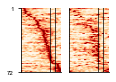

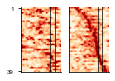

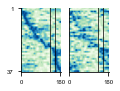

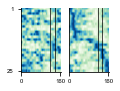

In [23]:
# SVG format
for strain in ['CKII','SST']:
    if strain=='CKII':
        spine_color=PYR_COLOR
        cmap = 'OrRd'
        mat_to_plot_reg1=CKII_reg1 ; mat_to_plot_reg2=CKII_reg2 ; mat_to_plot_fam=CKII_nov_nov_tuned ; mat_to_plot_nov=CKII_fam_nov_tuned
    else:
        spine_color=IN_COLOR
        cmap = 'GnBu'
        mat_to_plot_reg1=SST_reg1 ; mat_to_plot_reg2=SST_reg2 ; mat_to_plot_fam=SST_nov_nov_tuned ; mat_to_plot_nov=SST_fam_nov_tuned

    norm_mat_to_plot_reg1=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_reg1[1:]])
    norm_mat_to_plot_reg2=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_reg2[1:]])
    norm_mat_to_plot_fam=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_fam[1:]])
    norm_mat_to_plot_nov=np.array([normalize(FR_vec) for FR_vec in mat_to_plot_nov[1:]])

    #if a row is NaN, replace it with zeros
    norm_mat_to_plot_reg1[np.isnan(norm_mat_to_plot_reg1)]=0 ; norm_mat_to_plot_reg2[np.isnan(norm_mat_to_plot_reg2)]=0; norm_mat_to_plot_fam[np.isnan(norm_mat_to_plot_fam)]=0; norm_mat_to_plot_nov[np.isnan(norm_mat_to_plot_nov)]=0; 

    sorted_norm_array_reg1,sorted_indices_reg1 = sort_rows_by_max_index(norm_mat_to_plot_reg1)
    sorted_norm_array_reg2=norm_mat_to_plot_reg2[sorted_indices_reg1]
    sorted_norm_array_fam,sorted_indices_fam = sort_rows_by_max_index(norm_mat_to_plot_fam)
    sorted_norm_array_nov=norm_mat_to_plot_nov[sorted_indices_fam]

    #plot as two subplots 
    figsize_mm = (40,30)
    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig,ax=plt.subplots(1,2,figsize=figsize_inch)
    ax[0].imshow(sorted_norm_array_reg1,aspect='auto',cmap=cmap)
    ax[0].set_yticks([0,(len(sorted_norm_array_reg1))-1],[1,len(sorted_norm_array_reg1)],fontsize=SVG_TICKS)
    if strain=='SST':
        ax[0].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[0].set_xticks([])
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[0].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    ax[1].imshow(sorted_norm_array_reg2,aspect='auto',cmap=cmap)
    ax[1].set_yticks([])
    if strain=='SST':
        ax[1].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[1].set_xticks([])
    #remove top and right spines
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[1].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    #remove background color
    fig.patch.set_alpha(0)

    #add spacing between the two subplots
    plt.subplots_adjust(wspace=0.2)
    plt.show()

    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig,ax=plt.subplots(1,2,figsize=figsize_inch)
    ax[0].imshow(sorted_norm_array_nov,aspect='auto',cmap=cmap)
    ax[0].set_yticks([0,(len(sorted_norm_array_nov))-1],[1,len(sorted_norm_array_nov)],fontsize=SVG_TICKS)
    if strain=='SST':
        ax[0].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[0].set_xticks([])
    # for spine in ax[0].spines.values():
    #     spine.set_edgecolor(col)
    #     spine.set_linewidth(3)
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[0].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    ax[1].imshow(sorted_norm_array_fam,aspect='auto',cmap=cmap)
    ax[1].set_yticks([])
    if strain=='SST':
        ax[1].set_xticks([0,47],[0,160],fontsize=SVG_TICKS)
    else:
        ax[1].set_xticks([])

    #remove top and right spines
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    ax[1].axvline(x=35, color='k',alpha=0.7,linewidth=1)
    ax[1].axvline(x=40, color='k',alpha=0.7,linewidth=1)

    #remove background color
    fig.patch.set_alpha(0)

   
    #add spacing between the two subplots
    plt.subplots_adjust(wspace=0.2)
    plt.show()

    







# 7e

In [70]:
#find the correlation between each two rows of the matrix
CKII_reg1_arr=np.array(CKII_reg1[1:]);CKII_reg2_arr=np.array(CKII_reg2[1:]);CKII_fam_arr=np.array(CKII_fam[1:]);CKII_nov_arr=np.array(CKII_nov[1:])
SST_reg1_arr=np.array(SST_reg1[1:]);SST_reg2_arr=np.array(SST_reg2[1:]);SST_fam_arr=np.array(SST_fam[1:]);SST_nov_arr=np.array(SST_nov[1:])

CKII_reg1_reg2=[np.corrcoef(CKII_reg1_arr[i],CKII_reg2_arr[i])[0,1] for i in np.arange(CKII_reg1_arr.shape[0])]
CKII_fam_nov=[np.corrcoef(CKII_fam_arr[i],CKII_nov_arr[i])[0,1] for i in np.arange(CKII_fam_arr.shape[0])]
SST_reg1_reg2=[np.corrcoef(SST_reg1_arr[i],SST_reg2_arr[i])[0,1] for i in np.arange(SST_reg1_arr.shape[0])]
SST_fam_nov=[np.corrcoef(SST_fam_arr[i],SST_nov_arr[i])[0,1] for i in np.arange(SST_fam_arr.shape[0])]

             

In [71]:
data_dict = {'CKII regs': CKII_reg1_reg2,
             'CKII fam-nov': CKII_fam_nov,
             'SST regs': SST_reg1_reg2,
             'SST fam-nov': SST_fam_nov}
colors = [PYR_COLOR, 'indianred', IN_COLOR, 'cornflowerblue']

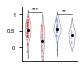

CKII regs, Shapiro: 0.06287154787075534
CKII fam-nov, Shapiro: 0.04637508704041626
SST regs, Shapiro: 0.0811314700801316
SST fam-nov, Shapiro: 0.5945672718942028
CKII regs vs fam-nov, Ranksums: 0.0
SST regs vs fam-nov, Ranksums: 0.00192
CKII regs vs fam-nov, T-test: 2.03e-08
SST regs vs fam-nov, T-test: 0.00244
CKII regs mean +- sem: (0.518, 0.027)
CKII fam-nov mean +- sem: (0.202, 0.05)
SST regs mean +- sem: (0.562, 0.033)
SST fam-nov mean +- sem: (0.367, 0.049)


In [74]:
def plot_violin_with_scatter_ver2(
    data_dict, colors, figsize_mm=(12.5, 25), width=0.5, ylim=None,
    linewidth=0.5, jitter=0.02, scatter_size=2, alpha=0.3,
    edgecolor='gray', inner_linewidth=0.5, yticks=[0, 5, 10], ylabel=None,
    significance_pairs=None, significance_labels=None, SVG_TICKS=10, SVG_LABELS=10
):
    figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)

    data = [data_dict[label] for label in data_dict.keys()]
    sns.violinplot(data=data, color='white', linewidth=linewidth, width=width,
                   zorder=0, alpha=1, inner=None, ax=ax)

    # Set violin outlines
    for collection in ax.collections:
        collection.set_edgecolor(edgecolor)
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(inner_linewidth)

    # Scatter points with jitter
    for i, (label, color) in enumerate(zip(data_dict.keys(), colors)):
        jitter_x = np.random.normal(i, jitter, size=len(data_dict[label]))
        ax.scatter(jitter_x, data_dict[label], color=color, s=scatter_size,
                   alpha=alpha, edgecolors='none')
    # Add group means
    for i, label in enumerate(data_dict.keys()):
        ax.scatter(i, np.nanmean(data_dict[label]), color='k', s=scatter_size*2, zorder=2)

    # Axes setup
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=SVG_TICKS)
    ax.set_xticks([])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=SVG_LABELS)
    if ylim:
        ax.set_ylim(ylim)
    else:
        y_max = max([max(v) for v in data_dict.values()])
        ax.set_ylim([0, y_max * 1.2])

    # Significance annotations
    if significance_pairs and significance_labels:
        for (x1, x2), label in zip(significance_pairs, significance_labels):
            y_max_pair = max([max(data[x1]), max(data[x2])])
            y = y_max_pair + (ylim[1] * 0.1 if ylim else y_max_pair * 0.1)
            h = (ylim[1] * 0.01 if ylim else y_max_pair * 0.01)
            ax.plot([x1, x1, x2, x2], [y, y, y, y], lw=0.5, c='k')
            ax.text((x1 + x2) / 2, y + h, label, ha='center', va='bottom',
                    color='k', fontsize=SVG_TICKS)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')

    plt.show()
    return fig, ax


fig,ax=plot_violin_with_scatter_ver2(
    data_dict, colors,
    figsize_mm=(25, 25), width=0.5, ylim=[-0.4, 1.2],
    linewidth=0.5, jitter=0.03, scatter_size=2, alpha=0.5,
    edgecolor='gray', inner_linewidth=0.5, yticks=[0, 0.5, 1], ylabel=None,
    significance_pairs=[(0,1), (2,3)],
    significance_labels=['***', '**'],
    SVG_TICKS=SVG_TICKS, SVG_LABELS=SVG_LABELS
)
#print shapiro test
print("CKII regs, Shapiro:", stats.shapiro(CKII_reg1_reg2,nan_policy='omit').pvalue)
print("CKII fam-nov, Shapiro:", stats.shapiro(CKII_fam_nov,nan_policy='omit').pvalue)
print("SST regs, Shapiro:", stats.shapiro(SST_reg1_reg2,nan_policy='omit').pvalue)
print("SST fam-nov, Shapiro:", stats.shapiro(SST_fam_nov,nan_policy='omit').pvalue)

#print ranksum test 
print("CKII regs vs fam-nov, Ranksums:", round(stats.ranksums(CKII_reg1_reg2, CKII_fam_nov,nan_policy='omit').pvalue, 5))
print("SST regs vs fam-nov, Ranksums:", round(stats.ranksums(SST_reg1_reg2, SST_fam_nov,nan_policy='omit').pvalue, 5))

#print t-test
print("CKII regs vs fam-nov, T-test:", round(stats.ttest_ind(CKII_reg1_reg2, CKII_fam_nov,nan_policy='omit').pvalue, 5))
print("SST regs vs fam-nov, T-test:", round(stats.ttest_ind(SST_reg1_reg2, SST_fam_nov,nan_policy='omit').pvalue, 5))

#print means +- sems
def mean_sem(data):
    mean = round(np.nanmean(data), 3)
    sem = round(stats.sem(data, nan_policy='omit'), 3)
    return mean, sem
print("CKII regs mean +- sem:", mean_sem(CKII_reg1_reg2))
print("CKII fam-nov mean +- sem:", mean_sem(CKII_fam_nov))
print("SST regs mean +- sem:", mean_sem(SST_reg1_reg2))
print("SST fam-nov mean +- sem:", mean_sem(SST_fam_nov))



# 7f

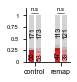

Strain: CKII
Control 1st half: 0.24 (55/226), 95% CI: 0.19 - 0.3
Control 2nd half: 0.23 (53/226), 95% CI: 0.18 - 0.29, p=0.8254028702971065
Remap 1st half: 0.29 (47/160), 95% CI: 0.23 - 0.37
Remap 2nd half: 0.24 (39/160), 95% CI: 0.18 - 0.32, p=0.31306749888837404


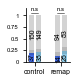

Strain: SST
Control 1st half: 0.2 (37/187), 95% CI: 0.15 - 0.26
Control 2nd half: 0.2 (38/187), 95% CI: 0.15 - 0.27, p=0.8972448026405802
Remap 1st half: 0.13 (14/108), 95% CI: 0.08 - 0.21
Remap 2nd half: 0.23 (25/108), 95% CI: 0.16 - 0.32, p=0.05167746304063456


In [ ]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

figsize_mm = (20, 25)
figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)

for strain in ["CKII", "SST"]:

    num_PCs_fam = 0
    num_PCs_nov = 0
    num_PCs_reg1 = 0
    num_PCs_reg2 = 0

    remap_cells_strain = [cell for cell in remap_cells if cell.strain == strain]
    reg_cells_strain = [cell for cell in reg_cells if cell.strain == strain]

    for cell in remap_cells_strain:
        if is_PC_with_halves_all_cells[cell.strain][cell.name]['first_half']:
            num_PCs_fam += 1
        if is_PC_with_halves_all_cells[cell.strain][cell.name]['second_half']:
            num_PCs_nov += 1

    for cell in reg_cells_strain:
        if is_PC_with_halves_all_cells[cell.strain][cell.name]['first_half']:
            num_PCs_reg1 += 1
        if is_PC_with_halves_all_cells[cell.strain][cell.name]['second_half']:
            num_PCs_reg2 += 1

    fig, ax = plt.subplots(figsize=figsize_inch)

    barWidth = 0.25
    within_gap = 0.08
    group_gap = 1.2

    # control 1st, control 2nd, remap 1st, remap 2nd
    x = np.array([
        0,
        barWidth + within_gap,
        group_gap,
        group_gap + barWidth + within_gap
    ])

    pc_counts = np.array([
        num_PCs_reg1,
        num_PCs_reg2,
        num_PCs_fam,
        num_PCs_nov
    ])

    total_counts = np.array([
        len(reg_cells_strain),
        len(reg_cells_strain),
        len(remap_cells_strain),
        len(remap_cells_strain)
    ])

    non_pc_counts = total_counts - pc_counts

    pc_props = pc_counts / total_counts
    non_pc_props = 1 - pc_props

    # if strain == 'CKII':
    #     half_colors = [PYR_COLOR, 'indianred', PYR_COLOR, 'indianred']
    # else:
    #     half_colors = [IN_COLOR, 'cornflowerblue', IN_COLOR, 'cornflowerblue']
    if strain == 'CKII':
        half_colors = [PYR_COLOR, '#ff9aa2', PYR_COLOR, '#ff9aa2']
    else:
        half_colors = [IN_COLOR, '#8ecae6', IN_COLOR, '#8ecae6']
    # bars
    for i in range(len(x)):

        plt.bar(
            x[i],
            pc_props[i],
            width=barWidth,
            color=half_colors[i],
            zorder=2
        )

        plt.bar(
            x[i],
            non_pc_props[i],
            width=barWidth,
            bottom=pc_props[i],
            color='lightgray',
            zorder=1
        )

    # Wilson 95% CI shading for PC proportion
    ci_lows = []
    ci_highs = []

    for count_i, total_i in zip(pc_counts, total_counts):
        ci_low, ci_high = proportion_confint(
            count=count_i,
            nobs=total_i,
            alpha=0.05,
            method='wilson'
        )
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)

    for i in range(len(x)):
        left = x[i] - barWidth / 2
        right = x[i] + barWidth / 2

        plt.fill_between(
            [left, right],
            [ci_lows[i], ci_lows[i]],
            [ci_highs[i], ci_highs[i]],
            color='k',
            alpha=0.12,
            linewidth=0,
            zorder=3
        )

    # vertical counts inside each segment
    text_offset = 0.04
    for i in range(len(x)):

        plt.text(
            x[i]+text_offset,
            pc_props[i] / 2,
            f'{pc_counts[i]}',
            ha='center',
            va='center',
            rotation=90,
            color='k',
            fontsize=SVG_LABELS
        )

        plt.text(
            x[i]+text_offset,
            pc_props[i] + non_pc_props[i] / 2,
            f'{non_pc_counts[i]}',
            ha='center',
            va='center',
            rotation=90,
            color='k',
            fontsize=SVG_LABELS
        )

    control_center = np.mean(x[:2])
    remap_center = np.mean(x[2:])

    plt.xticks(
        [control_center, remap_center],
        ['control', 'remap'],
        fontsize=SVG_LABELS
    )

    plt.yticks(
        [0, 0.25, 0.5, 0.75, 1],
        [0, 0.25, 0.5, 0.75, 1],
        fontsize=SVG_TICKS
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.ylabel('', fontsize=SVG_LABELS)

    ax.set_ylim(0, 1.15)

    # stats: first vs second half within control
    count = np.array([num_PCs_reg1, num_PCs_reg2])
    nobs = np.array([len(reg_cells_strain), len(reg_cells_strain)])
    z_reg, p_reg = proportions_ztest(count, nobs)

    # stats: first vs second half within remap
    count = np.array([num_PCs_fam, num_PCs_nov])
    nobs = np.array([len(remap_cells_strain), len(remap_cells_strain)])
    z_remap, p_remap = proportions_ztest(count, nobs)

    # significance labels
    ylim = ax.get_ylim()

    control_y = ylim[1] * 0.92
    remap_y = ylim[1] * 0.92
    text_y = ylim[1] * 0.95

    plt.plot(
        [x[0], x[1]],
        [control_y, control_y],
        color='black',
        linewidth=0.5
    )

    plt.plot(
        [x[2], x[3]],
        [remap_y, remap_y],
        color='black',
        linewidth=0.5
    )

    plt.text(
        control_center,
        text_y,
        'n.s',
        fontsize=SVG_TICKS,
        ha='center'
    )

    plt.text(
        remap_center,
        text_y,
        'n.s',
        fontsize=SVG_TICKS,
        ha='center'
    )

    ax.set_xlim(-0.25, group_gap + barWidth + within_gap + 0.25)

    print(f"Strain: {strain}")

    print(
        f"Control 1st half: {round(num_PCs_reg1 / len(reg_cells_strain), 2)} "
        f"({num_PCs_reg1}/{len(reg_cells_strain)}), "
        f"95% CI: {round(ci_lows[0], 2)} - {round(ci_highs[0], 2)}"
    )

    print(
        f"Control 2nd half: {round(num_PCs_reg2 / len(reg_cells_strain), 2)} "
        f"({num_PCs_reg2}/{len(reg_cells_strain)}), "
        f"95% CI: {round(ci_lows[1], 2)} - {round(ci_highs[1], 2)}, "
        f"p={p_reg}"
    )

    print(
        f"Remap 1st half: {round(num_PCs_fam / len(remap_cells_strain), 2)} "
        f"({num_PCs_fam}/{len(remap_cells_strain)}), "
        f"95% CI: {round(ci_lows[2], 2)} - {round(ci_highs[2], 2)}"
    )

    print(
        f"Remap 2nd half: {round(num_PCs_nov / len(remap_cells_strain), 2)} "
        f"({num_PCs_nov}/{len(remap_cells_strain)}), "
        f"95% CI: {round(ci_lows[3], 2)} - {round(ci_highs[3], 2)}, "
        f"p={p_remap}"
    )

# 7g

In [35]:
SST_reg_cells = [cell for cell in reg_cells if cell.strain == "SST"]
SST_remap_cells = [cell for cell in remap_cells if cell.strain == "SST"]


with open('data_analysis/result_dictionaries/inst_speed_r_vals_with_halves_all_cells.pkl', 'rb') as f:
    inst_speed_r_vals_with_halves_all_cells = pickle.load(f)

In [51]:
strain = "SST"
inst_r_vals_frst_half_reg = []; inst_r_vals_scnd_half_reg = []
inst_r_vals_frst_half_reg_all_cells = []; inst_r_vals_scnd_half_reg_all_cells = []
results_dict_to_export = {}
for cell in SST_reg_cells:
    r_val_frst = inst_speed_r_vals_with_halves_all_cells[cell.strain][cell.name]['first_half']
    r_val_scnd = inst_speed_r_vals_with_halves_all_cells[cell.strain][cell.name]['second_half']
    inst_r_vals_frst_half_reg_all_cells.append(r_val_frst)
    inst_r_vals_scnd_half_reg_all_cells.append(r_val_scnd)
    if is_speed_tuned_with_halves_all_cells[cell.strain][cell.name]['first_half'] == True or \
       is_speed_tuned_with_halves_all_cells[cell.strain][cell.name]['second_half'] == True:
        inst_r_vals_frst_half_reg.append(r_val_frst)
        inst_r_vals_scnd_half_reg.append(r_val_scnd)
        results_dict_to_export[cell] = {
            'r_val_first_half': r_val_frst,
            'r_val_second_half': r_val_scnd
        }

inst_r_vals_fam =[]; inst_r_vals_nov = []
inst_r_vals_fam_all_cells = []; inst_r_vals_nov_all_cells = []
for cell in SST_remap_cells:
    r_val_frst = inst_speed_r_vals_with_halves_all_cells[cell.strain][cell.name]['first_half']
    r_val_scnd = inst_speed_r_vals_with_halves_all_cells[cell.strain][cell.name]['second_half']
    inst_r_vals_fam_all_cells.append(r_val_frst)
    inst_r_vals_nov_all_cells.append(r_val_scnd)
    if is_speed_tuned_with_halves_all_cells[cell.strain][cell.name]['first_half'] == True or \
       is_speed_tuned_with_halves_all_cells[cell.strain][cell.name]['second_half'] == True:
        inst_r_vals_fam.append(r_val_frst)
        inst_r_vals_nov.append(r_val_scnd)
        results_dict_to_export[cell] = {
            'r_val_first_half': r_val_frst,
            'r_val_second_half': r_val_scnd
        }
        


In [47]:
def generate_n_shuffled_means_on_array_diffs(array1, array2, n_shuffles=10000):
    """
    Generate n shuffled means on the differences between two arrays.
    """
    diffs = np.abs(array1 - array2)
    observed_mean = np.mean(diffs)
    shuffled_means = []
    for _ in range(n_shuffles):
        shuffled_array1 = np.random.permutation(array1)
        shuffled_mean = np.mean(np.abs(shuffled_array1 - array2))
        shuffled_means.append(shuffled_mean)
    shuffled_means = np.array(shuffled_means)
    p_value = (np.sum(shuffled_means <= observed_mean) + 1) / (n_shuffles + 1)
    return diffs,observed_mean, shuffled_means, p_value

# Define datasets
datasets = [
    ('Reg inst_r speed tuned', inst_r_vals_frst_half_reg, inst_r_vals_scnd_half_reg),
    ('Remap inst_r speed tuned', inst_r_vals_fam, inst_r_vals_nov),

]

# Initialize result storage
results = {}

# Loop and compute
for name, arr1, arr2 in datasets:
    diffs,observed_mean, shuffled_means, p_value = generate_n_shuffled_means_on_array_diffs(np.array(arr1), np.array(arr2))
    results[name] = {
        'diffs': diffs,
        'observed_mean': observed_mean,
        'shuffled_means': shuffled_means,
        'p_value': p_value
    }


Shapiro-W0: 6.218732729006994e-07, Shapiro-W2: 0.0006358029938123411
Data is not normally distributed, using non-parametric test.
RanksumsResult(statistic=-0.6923568554867183, pvalue=0.4887132532643961)
Mean reg: 0.142 ± 0.010, Mean remap: 0.158 ± 0.015


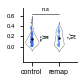

In [ ]:
def plot_W0_W2_violins_with_histograms(result_dict, shuffled_distributions, cell_name,
                                       palette=[PYR_COLOR, PYR_COLOR_weak],
                                       ylabel=False, yticks=np.arange(-0.5, 1.1, 0.5), ylims=(-0.7, 1.5),
                                       save_path=None, SVG_TICKS=6, SVG_LABELS=6, figsize_mm=(12.5, 25),
                                       rotation =0, title='',offset=0.3, paired=True, key_type='W0W2'):
    from scipy.stats import gaussian_kde, ttest_rel, ttest_ind

    # Determine keys based on key_type
    if key_type == 'W0W2':
        key1, key2 = 'W0_W0', 'W0_W2'
        xtick_labels = ['W0-W0', 'W0-W2']
    elif key_type == 'RegRemap':
        key1, key2 = 'Reg', 'Remap'
        xtick_labels = ['control', 'remap']
    else:
        raise ValueError("key_type must be either 'W0W2' or 'RegRemap'")
    if paired:
        W0_values = [res[key1] for res in result_dict.values()]
        W2_values = [res[key2] for res in result_dict.values()]
    else:
        W0_values = result_dict[key1]
        W2_values = result_dict[key2]
    shuffled_means = [np.mean(dist) for dist in shuffled_distributions]

    # Stats: paired or unpaired
    shapiro_w0 = stats.shapiro(W0_values)[1]
    shapiro_w2 = stats.shapiro(W2_values)[1]
    print(f"Shapiro-W0: {shapiro_w0}, Shapiro-W2: {shapiro_w2}")
    if shapiro_w0 < 0.05 or shapiro_w2 < 0.05:
        print("Data is not normally distributed, using non-parametric test.")
        if paired:
            p = stats.wilcoxon(W0_values, W2_values)[1]
            print(stats.wilcoxon(W0_values, W2_values))
        else:
            p = stats.ranksums(W0_values, W2_values)[1]
        print(stats.ranksums(W0_values, W2_values))
    else:
        if paired:
            p = ttest_rel(W0_values, W2_values)[1]
            print(stats.ttest_rel(W0_values, W2_values))
        else:
            p = ttest_ind(W0_values, W2_values)[1]
            print(stats.ttest_ind(W0_values, W2_values))

    # Setup
    figsize_inch = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)

    # Violin plots
    sns.violinplot(data=[W0_values, W2_values], color='white', linewidth=0.5, width=0.5,
                   zorder=0, alpha=1, inner=None, ax=ax)
    for collection in ax.collections:
        collection.set_edgecolor('gray')
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.5)

    # Scatter points with jitter
    jitter_0 = np.random.normal(0, 0.02, size=len(W0_values))
    jitter_1 = np.random.normal(0, 0.02, size=len(W2_values))
    ax.scatter(np.zeros(len(W0_values)) + jitter_0, W0_values, color=palette[0], s=2, alpha=0.8, edgecolors='none')
    ax.scatter(np.ones(len(W2_values)) + jitter_1, W2_values, color=palette[1], s=2, alpha=0.8, edgecolors='none')

    # Connect lines (only if paired)
    if paired:
        for i in range(min(len(W0_values), len(W2_values))):
            ax.plot([0 + jitter_0[i], 1 + jitter_1[i]], [W0_values[i], W2_values[i]],
                    color='gray', alpha=0.5, linewidth=0.5)

    # Mean points
    ax.scatter(0, np.mean(W0_values), color='k', s=2, zorder=2)
    ax.scatter(1, np.mean(W2_values), color='k', s=2, zorder=2)
    
    #print mean and SEM
    mean_w0 = np.mean(W0_values)
    sem_w0 = stats.sem(W0_values)
    mean_w2 = np.mean(W2_values)
    sem_w2 = stats.sem(W2_values)
    print(f"Mean reg: {mean_w0:.3f} ± {sem_w0:.3f}, Mean remap: {mean_w2:.3f} ± {sem_w2:.3f}")
    

    # KDE histograms
    histogram_offset = offset
    for i, (shuffled, x_center) in enumerate(zip(shuffled_distributions, [0, 1])):
        kde = gaussian_kde(shuffled)
        y_vals = np.linspace(min(shuffled), max(shuffled), 300)
        density = kde(y_vals)
        density = density / np.max(density) * 0.2
        ax.plot(x_center + histogram_offset + density, y_vals, color='k', linewidth=0.7, alpha=0.7)
        lower, upper = np.percentile(shuffled, [1, 99])
        ax.plot([x_center + histogram_offset, x_center + histogram_offset + 0.2], [lower, lower],
                color='k', linestyle='--', linewidth=0.6)
        ax.plot([x_center + histogram_offset, x_center + histogram_offset + 0.2], [upper, upper],
                color='k', linestyle='--', linewidth=0.6)
        obs_mean = np.mean(W0_values) if i == 0 else np.mean(W2_values)
        p_val = 2 * min(np.mean(shuffled >= obs_mean), np.mean(shuffled <= obs_mean))
        y_peak = y_vals[np.argmax(density)]
        if p_val > 0.05:
            shuffle_sig = "n.s."
        elif p_val < 0.001:
            shuffle_sig = "***"
        elif p_val < 0.01:
            shuffle_sig = "**"
        else:
            shuffle_sig = "*"
        ax.text(x_center + histogram_offset, y_peak, shuffle_sig, ha='center', va='center',
                fontsize=SVG_TICKS, rotation=90)

    # Y axis
    ax.set_ylim(ylims)
    ax.set_yticks(yticks)
    ax.tick_params(axis='y', labelsize=SVG_TICKS)
    ax.set_xticks([0, 1], xtick_labels, fontsize=SVG_LABELS, rotation=rotation)
    ax.set_title(title, fontsize=SVG_LABELS)

    # Overall significance annotation
    y_lim = ax.get_ylim()
    x_center = 0.5
    if p > 0.05:
        sig_label = "n.s"
    elif p < 0.001:
        sig_label = "***"
    elif p < 0.01:
        sig_label = "**"
    else:
        sig_label = "*"
    ax.text(x_center, y_lim[1] * 0.9, sig_label, ha='center', va='bottom', color='k', fontsize=SVG_TICKS)
    #plot a line below the significance label
    plt.plot([0, 1], [y_lim[1] * 0.85, y_lim[1] * 0.85], color='k', linewidth=0.5)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=SVG_LABELS)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.patch.set_facecolor('none')

    if save_path:
        plt.savefig(save_path, dpi=300, format=save_path.split('.')[-1], bbox_inches='tight')

    return fig, ax


r_vals_remapping_dict_inst = {
    'Reg': results['Reg inst_r speed tuned']['diffs'],
    'Remap': results['Remap inst_r speed tuned']['diffs']
}

plot_W0_W2_violins_with_histograms(r_vals_remapping_dict_inst,[results['Reg inst_r speed tuned']['shuffled_means'],
                            results['Remap inst_r speed tuned']['shuffled_means']], "SST", palette=[IN_COLOR, IN_COLOR_weak], ylabel="",
                            yticks=[0,0.2,0.4,0.6], ylims=(-0.3, 0.75),
                            save_path=False,
                            SVG_TICKS=SVG_TICKS, SVG_LABELS=SVG_LABELS,figsize_mm=(25, 25),offset=0.4,
                            paired=False,key_type='RegRemap',title='')



# 7h

In [6]:
reg_cells = [cell for cell in cell_objects if cell.remapping==False and cell.session_num==0]
remap_cells = [cell for cell in cell_objects if cell.remapping==True and cell.session_num==0]

## Control

In [4]:
def classify_cells_longi(cell, strain, cond):
    if is_PC_with_halves_all_cells[strain][cell.name][cond] and is_speed_tuned_with_halves_all_cells[strain][cell.name][cond]:
        return "both"
    elif is_speed_tuned_with_halves_all_cells[strain][cell.name][cond]:
        return "speed"
    elif is_PC_with_halves_all_cells[strain][cell.name][cond]:
        return "space"
    elif not is_spatially_modulated_all_cells[strain][cell.name][cond]:
        return "uniform"
    else:
        return "non-tuned"
    
from matplotlib.patches import PathPatch
from matplotlib.path import Path

def create_bezier_curve(x1, y1, x2, y2, curvature=0.4):
    verts = [(x1, y1), (x1 + curvature, y1), (x2 - curvature, y2), (x2, y2)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    return Path(verts, codes)

def calculate_positions(counts, categories, spacing):
    return np.cumsum([counts[cat] + spacing for cat in categories]) - \
           np.array([(counts[cat] + spacing) / 2 for cat in categories])

def compute_ordered_y_positions(counts, positions, categories):
    return {
        cat: [positions[i] - counts[cat]/2 + j + 0.5 for j in range(counts[cat])]
        for i, cat in enumerate(categories)
    }

def plot_sankey_svg_style(
    fam_counts, nov_counts, transitions, strain,
    figsize_mm=(30, 60), svg_label_size=10, spacing=5,
    xticklabels=("Fam 1", "Fam 2"), svg_path=None
):
    if strain == "CKII":
        categories = ["tuned", "non-tuned"]
    else:
        categories = ["speed", "both", "space", "uniform", "non-tuned"]

    colors = {
        "speed": "blue", "space": "green", "both": "purple",
        "uniform": "orange", "non-tuned": "gray", "tuned": "green"
    }

    # Compute stacked positions
    fam_pos = calculate_positions(fam_counts, categories, spacing)
    nov_pos = calculate_positions(nov_counts, categories, spacing)

    # Prepare transitions
    sorted_transitions = {cat: [] for cat in categories}
    for f, n in transitions:
        sorted_transitions[f].append((f, n))
    for cat in categories:
        sorted_transitions[cat].sort(key=lambda x: categories.index(x[1]))

    # Setup figure
    figsize_inch = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)
    fig, ax = plt.subplots(figsize=figsize_inch)
    x_fam, x_nov = 0, 1

    # Draw stacked bars
    for i, cat in enumerate(categories):
        ax.bar(x_fam, fam_counts[cat], bottom=fam_pos[i] - fam_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black", linewidth=0.3)
        ax.bar(x_nov, nov_counts[cat], bottom=nov_pos[i] - nov_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black", linewidth=0.3)

    # Compute curve anchors
    fam_y = compute_ordered_y_positions(fam_counts, fam_pos, categories)
    nov_y = compute_ordered_y_positions(nov_counts, nov_pos, categories)

    # Draw curves
    for fam_cat in categories:
        for _, nov_cat in sorted_transitions[fam_cat]:
            if fam_y[fam_cat] and nov_y[nov_cat]:
                y1 = fam_y[fam_cat].pop(0)
                y2 = nov_y[nov_cat].pop(0)
                path = create_bezier_curve(x_fam + 0.1, y1, x_nov - 0.1, y2)
                patch = PathPatch(path, facecolor='none', edgecolor=colors[fam_cat], alpha=0.7, lw=1)
                ax.add_patch(patch)

    # Format axes
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, max(fam_pos[-1], nov_pos[-1]) + spacing)
    ax.set_xticks([x_fam, x_nov])
    ax.set_xticklabels(xticklabels, fontsize=svg_label_size)
    ax.set_yticks([])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Output
    plt.tight_layout()
    if svg_path:
        plt.savefig(svg_path, format='svg')
    plt.show()
    
def plot_sankey_standard(
    fam_counts, nov_counts, transitions, strain,
    figsize=(8, 8), spacing=5, title="Reg1 to Reg 2 (control) Tuning transitions",
    xticklabels=("Reg 1", "Reg 2"), label_fontsize=8, title_fontsize=15
):
    if strain == "CKII":
        categories = ["tuned", "non-tuned"]
    else:
        categories = ["speed", "both", "space", "uniform", "non-tuned"]

    colors = {
        "speed": "blue", "space": "green", "both": "purple",
        "uniform": "orange", "non-tuned": "gray", "tuned": "green"
    }

    # Compute bar positions
    fam_pos = calculate_positions(fam_counts, categories, spacing)
    nov_pos = calculate_positions(nov_counts, categories, spacing)

    # Organize transitions
    sorted_transitions = {cat: [] for cat in categories}
    for f, n in transitions:
        sorted_transitions[f].append((f, n))
    for cat in categories:
        sorted_transitions[cat].sort(key=lambda x: categories.index(x[1]))

    # Start figure
    fig, ax = plt.subplots(figsize=figsize)
    x_fam, x_nov = 0, 1

    total_fam = sum(fam_counts.values())
    total_nov = sum(nov_counts.values())

    # Plot bars + labels
    for i, cat in enumerate(categories):
        # Bars
        ax.bar(x_fam, fam_counts[cat], bottom=fam_pos[i] - fam_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black")
        ax.bar(x_nov, nov_counts[cat], bottom=nov_pos[i] - nov_counts[cat]/2,
               width=0.2, color=colors[cat], edgecolor="black")

        # Labels (category name + proportion)
        fam_prop = fam_counts[cat] / total_fam
        nov_prop = nov_counts[cat] / total_nov
        y_fam = fam_pos[i]
        y_nov = nov_pos[i]
        ax.text(x_fam, y_fam, f"{cat}\n{fam_prop:.2f}", ha='center', va='center',
                fontsize=label_fontsize, color='white', weight='bold')
        ax.text(x_nov, y_nov, f"{cat}\n{nov_prop:.2f}", ha='center', va='center',
                fontsize=label_fontsize, color='white', weight='bold')

    # Assign Y positions for curves
    fam_y = compute_ordered_y_positions(fam_counts, fam_pos, categories)
    nov_y = compute_ordered_y_positions(nov_counts, nov_pos, categories)

    # Draw transitions
    for fam_cat in categories:
        for _, nov_cat in sorted_transitions[fam_cat]:
            if fam_y[fam_cat] and nov_y[nov_cat]:
                y1 = fam_y[fam_cat].pop(0)
                y2 = nov_y[nov_cat].pop(0)
                path = create_bezier_curve(x_fam + 0.1, y1, x_nov - 0.1, y2)
                patch = PathPatch(path, facecolor='none', edgecolor=colors[fam_cat], alpha=0.7, lw=1)
                ax.add_patch(patch)

    # Final styling
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0, max(fam_pos[-1], nov_pos[-1]) + spacing)
    ax.set_xticks([x_fam, x_nov])
    ax.set_xticklabels(xticklabels, fontsize=label_fontsize+4)
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

categories = ["speed","both", "space",  "uniform", "non-tuned"]
colors = {
    "speed": "blue",
    "space": "green",
    "both": "purple",
    "uniform": "orange",
    "non-tuned": "gray",
    "tuned": "green"}

In [8]:
strain = "SST"
colors = {
    "speed": "blue",
    "space": "green",
    "both": "purple",
    "uniform": "orange",
    "non-tuned": "gray"
}
categories = ["speed", "space", "both", "uniform", "non-tuned"]
# Initialize data structures
cell_transitions_reg = []  # List of (fam_class, nov_class) transitions
counts_reg1 = {cat: 0 for cat in categories}
counts_reg2 = {cat: 0 for cat in categories}
results_dict_reg = {}
# Iterate over all cells and classify them in 'fam' and 'nov'
SST_cells = [cell for cell in cell_objects if cell.remapping == False and cell.session_num == 0 and cell.strain == "SST"]
for cell in SST_cells:
    fam_df, nov_df = cell.get_fam_and_novel_df_partial(laps_to_consider=10)
    if len(fam_df.lap_counter.unique()) < 8 or len(nov_df.lap_counter.unique()) < 8:
        continue

    # fam_class = classify_cells_control(cell.name,strain,'fam')
    # nov_class = classify_cells_control(cell.name,strain,'nov')
    reg1_class = classify_cells_longi(cell,cell.strain,'first_half')
    reg2_class = classify_cells_longi(cell,cell.strain,'second_half')

    # Add the transition to the list
    cell_transitions_reg.append((reg1_class, reg2_class))
    results_dict_reg[cell] = (reg1_class, reg2_class)

    # Count occurrences for fam and nov categories
    counts_reg1[reg1_class] += 1
    counts_reg2[reg2_class] += 1

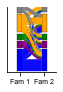

In [9]:
plot_sankey_svg_style(counts_reg1, counts_reg2, cell_transitions_reg, strain="SST",
                        figsize_mm=(25, 35), svg_label_size=SVG_LABELS,
                        xticklabels=("Fam 1", "Fam 2"), svg_path = 'your_desired_path_here')


## Remap

In [11]:
strain = "SST"

categories = ["speed","both", "space",  "uniform", "non-tuned"]

colors = {
    "speed": "blue",
    "space": "green",
    "both": "purple",
    "uniform": "orange",
    "non-tuned": "gray",
    "tuned": "green"}
# Initialize data structures
cell_transitions_remap = []  # List of (fam_class, nov_class) transitions
fam_counts_remap = {cat: 0 for cat in categories}
nov_counts_remap = {cat: 0 for cat in categories}
results_dict_remap = {}

# Iterate over all cells and classify them in 'fam' and 'nov'
SST_cells_remap = [cell for cell in remap_cells if cell.strain == "SST"]
for cell in SST_cells_remap:
    if cell.strain != strain:
        continue
    fam_df, nov_df = cell.get_fam_and_novel_df_partial(laps_to_consider=10)
    if len(fam_df.lap_counter.unique()) < 8 or len(nov_df.lap_counter.unique()) < 8:
        continue


    fam_class = classify_cells_longi(cell,strain, 'first_half')
    nov_class = classify_cells_longi(cell,strain, 'second_half')
    results_dict_remap[cell] = (fam_class, nov_class)


    # Add the transition to the list
    cell_transitions_remap.append((fam_class, nov_class))

    # Count occurrences for fam and nov categories
    fam_counts_remap[fam_class] += 1
    nov_counts_remap[nov_class] += 1

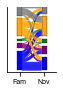

In [13]:
plot_sankey_svg_style(fam_counts_remap, nov_counts_remap, cell_transitions_remap, strain="SST",
                        figsize_mm=(25, 35), svg_label_size=SVG_LABELS,
                        xticklabels=("Fam", "Nov"), svg_path='your_desired_path_here')

